In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.datasets import load_digits  # Dữ liệu ví dụ
from sklearn.impute import SimpleImputer

In [2]:
# Đọc dữ liệu từ file CSV (thay 'data.csv' bằng đường dẫn file của bạn)
df = pd.read_csv("data/csv/cicddos_2019_4_labels.csv")

In [3]:
# Giả sử cột cuối cùng là nhãn, các cột còn lại là đặc trưng
X = df.drop(columns=['Label'])  # Tất cả các cột trừ cột cuối (features)
y = df['Label']   # Cột cuối cùng là nhãn (labels)


In [4]:
X.replace([-np.inf, np.inf], 0, inplace=True)
X.fillna(X.mean(), inplace=True)  # Điền giá trị NaN bằng giá trị trung vị

std = X.std()
std.replace(0, 1, inplace=True)

X = (X - X.mean()) / std
X = np.log1p(X + 1)

scaler = MinMaxScaler(feature_range=(0, 255))
X_scaled = scaler.fit_transform(X).astype(np.uint8)

# Tạo DataFrame mới nhưng giữ lại index và column names
X = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

f:\NCKH\code\DN\IDS-RESNET-50-System\train_model\.venv\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
C:\Users\NewTun\AppData\Local\Temp\ipykernel_10952\3977766833.py:11: RuntimeWarning: invalid value encountered in cast
  X_scaled = scaler.fit_transform(X).astype(np.uint8)


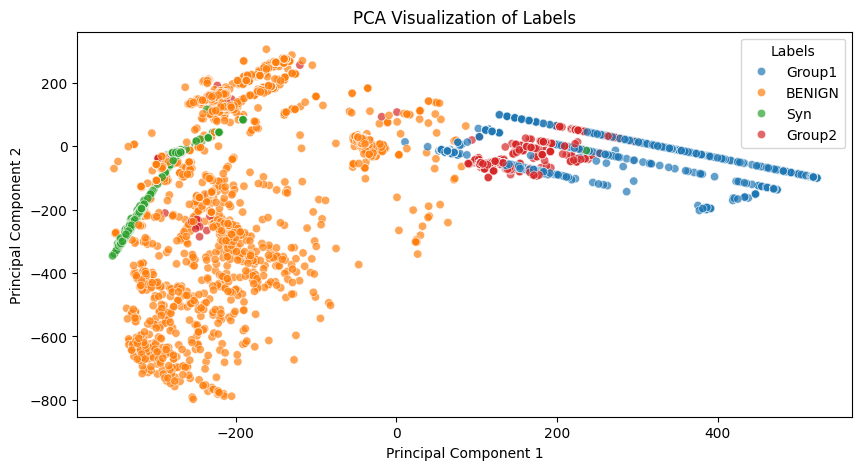

In [5]:
### 🔹 PCA để giảm xuống 2D ###
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="tab10", alpha=0.7)
plt.title("PCA Visualization of Labels")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Labels", bbox_to_anchor=(1, 1))
plt.show()

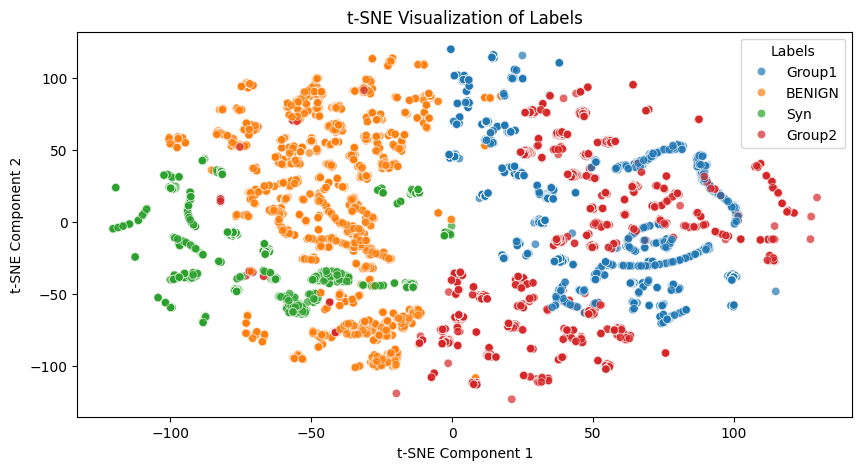

In [6]:
### 🔹 t-SNE để giảm xuống 2D ###
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="tab10", alpha=0.7)
plt.title("t-SNE Visualization of Labels")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Labels", bbox_to_anchor=(1, 1))
plt.show()